# AI Agents with Memory in LangGraph

The ReAct agent in `02_React_agents_with_langgraph` has no memory between calls. Every `graph.invoke(...)` starts from an empty state, so if you say *"My name is Sam"* and then ask *"What is my name?"* in a second call, the agent has no idea.

LangGraph adds memory with a **checkpointer**. After every step of the graph, the checkpointer saves a snapshot (a **checkpoint**) of the state. The next call on the same conversation picks up from that saved state instead of starting empty.

## Without vs. with memory

| | Without memory (notebook 02) | With memory |
|---|---|---|
| Compile | `builder.compile()` | `builder.compile(checkpointer=memory)` |
| Invoke | `graph.invoke({"messages": ...})` | `graph.invoke({"messages": ...}, config=config)` |
| State between calls | Lost after each call | Saved per `thread_id` and restored on the next call |
| *"What is my name?"* | Doesn't know | Remembers it from earlier in the same thread |

The nodes and edges do not change. Only the compile and invoke steps do.

## Core building blocks

| Concept | What it is | In code |
|---|---|---|
| **Checkpointer** | Saves the graph state after each step | `InMemorySaver()` (also available as `MemorySaver`) keeps checkpoints in RAM |
| **Thread** | One conversation; its checkpoints are grouped under a `thread_id` | `config = {"configurable": {"thread_id": "1"}}` |
| **Checkpoint** | A snapshot of the state at a point in time | Inspect it with `graph.get_state(config)` |
| **Reducer** | Merges new messages into the restored history | `add_messages` appends to the saved `messages` list |

## How it works

```
call 1 (thread_id="1"):  load state (empty)             ──▶ run graph ──▶ save checkpoint
call 2 (thread_id="1"):  load state (call 1's messages) ──▶ run graph ──▶ save checkpoint
call 3 (thread_id="2"):  load state (empty, new thread) ──▶ run graph ──▶ save checkpoint
```

Same `thread_id` means the same conversation. A new `thread_id` starts a fresh one.

## Short-term vs. long-term memory

- **Short-term (thread-level) memory:** the checkpointer. It remembers the conversation within one `thread_id`.
- **Long-term (cross-thread) memory:** a **store** such as `InMemoryStore`, passed as `builder.compile(checkpointer=..., store=...)`. It holds facts that should be shared across threads, like user preferences.

## Choosing a checkpointer

- `InMemorySaver`: good for notebooks and experiments. Everything is lost when the kernel restarts.
- `SqliteSaver` (`langgraph-checkpoint-sqlite`) or `PostgresSaver` (`langgraph-checkpoint-postgres`): persist checkpoints to a database for real applications.

> **Note:** the saved history grows with every turn. Long threads eventually exceed the model's context window, so real agents trim or summarize old messages (for example with `trim_messages`).

## Steps

1. **Reuse the ReAct agent**: same `State`, LLM node, `ToolNode`, and `tools_condition`.
2. **Create a checkpointer**: `memory = InMemorySaver()`.
3. **Compile with memory**: `graph = builder.compile(checkpointer=memory)`.
4. **Pick a thread**: `config = {"configurable": {"thread_id": "1"}}`.
5. **Chat across calls**: invoke several times with the same `config` and check that the agent remembers earlier messages; switch `thread_id` to see a fresh conversation.

In [1]:
import os
from dotenv import load_dotenv

# Change working directory to the parent folder
os.chdir(os.path.abspath(".."))
load_dotenv()

True

In [2]:
## State graph 
from typing import Annotated # context specific metadata 

from typing_extensions import TypedDict

from langgraph.graph.message import add_messages

from langgraph.graph import  StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

print("Import Successfull")

Import Successfull


In [3]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_results=3)


def web_search(query: str) -> dict:
    """Search the web for recent or real-time information. Use this tool for news or facts you don't know

    Args:
    query (str) The search query

    Returns:
    dict: Top 3 Tavily search results
    """

    return tavily.invoke(query)


web_search("What is quantum computing")


{'query': 'What is quantum computing',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/quantum-computing',
   'title': 'What is Quantum Computing?',
   'content': 'Quantum computing is a multidisciplinary field comprising aspects of computer science, physics, and mathematics that utilizes quantum mechanics to solve complex problems faster than on classical computers. The field of quantum computing includes hardware research and application development. Quantum computers are able to solve certain types of problems faster than classical computers by taking advantage of quantum mechanical effects, such as superposition and quantum interference. Some [...] Machine learning (ML) is the process of analyzing vast quantities of data to help computers make better predictions and decisions. Research in quantum computing studies the physical limits of information processing and is breaking new ground in fundamental physics. This r

In [4]:
## define custom function

def multiply(a:int, b:int)-> int:
    """Multiply a and b. Always use this tool for any multiplication
    
    Args: 
    a (int) First value
    b (int) Second value
    
    Returns:
    int: Output int
    """

    return a*b



In [5]:
from langchain_openai import ChatOpenAI


def get_llm_with_tools(tools: list, model: str = "gpt-5.1"):
    """Create the chat model and bind the tools to it, so it can request tool calls

    Args:
    tools (list) Tools the model is allowed to call
    model (str) OpenAI model name

    Returns:
    Runnable: The LLM with the tools bound
    """

    llm = ChatOpenAI(model=model)
    return llm.bind_tools(tools)


tools = [web_search, multiply]
llm_with_tool = get_llm_with_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5.1', 'release_date': '2025-11-13', 'last_updated': '2025-11-13', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x10fcaa7b0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x

In [6]:
## State and node definition

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    """Graph state: the conversation, with new messages appended by `add_messages`."""
    messages: Annotated[list, add_messages]


def tool_calling_llm(state: State):
    """Call the tool-aware LLM; its reply may contain tool calls."""
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

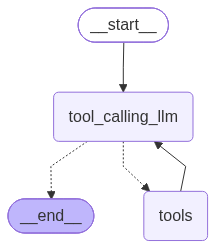

In [7]:
## Build the agent graph

def build_agent_graph(tools: list, checkpointer=None, model: str = "gpt-5.1"):
    """Build the ReAct agent: a tool-calling LLM node plus a ToolNode that runs the requested tools

    Args:
    tools (list) Tools the agent can use
    checkpointer Saves the state between calls, e.g. MemorySaver(). None means no memory
    model (str) OpenAI model name

    Returns:
    CompiledStateGraph: The compiled agent graph
    """

    llm_with_tool = get_llm_with_tools(tools, model)

    def tool_calling_llm(state: State):
        """Call the tool-aware LLM; its reply may contain tool calls."""
        return {"messages": [llm_with_tool.invoke(state["messages"])]}

    builder = StateGraph(State)
    builder.add_node("tool_calling_llm", tool_calling_llm)
    builder.add_node("tools", ToolNode(tools))

    builder.add_edge(START, "tool_calling_llm")
    ## If the reply has tool calls -> tools_condition routes to "tools", otherwise -> END
    builder.add_conditional_edges("tool_calling_llm", tools_condition)
    builder.add_edge("tools", "tool_calling_llm")

    return builder.compile(checkpointer=checkpointer)


memory = MemorySaver()
graph = build_agent_graph(tools, checkpointer=memory)
graph

In [8]:
## Thread id: every call with the same thread_id continues the same conversation

config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi, my name is KDB"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is KDB
================================== Ai Message ==================================

Nice to meet you, KDB!  

What would you like to do today—chat, get help with something specific, or work through a problem together?


In [9]:
response['messages'][-1]

AIMessage(content='Nice to meet you, KDB!  \n\nWhat would you like to do today—chat, get help with something specific, or work through a problem together?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 176, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-ES2qJ7VADXPkXR4PNJGTC00hQC4BF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0d957-ffa9-7473-8a07-9813276dd74b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 176, 'output_tokens': 41, 'total_tokens': 217, 'input_token_details': {

In [10]:
# config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hey, what is my name "}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is KDB
================================== Ai Message ==================================

Nice to meet you, KDB!  

What would you like to do today—chat, get help with something specific, or work through a problem together?
================================ Human Message =================================

Hey, what is my name 
================================== Ai Message ==================================

Your name is KDB.


In [11]:
response = graph.invoke({"messages": "Hey, Do you remember my name"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is KDB
================================== Ai Message ==================================

Nice to meet you, KDB!  

What would you like to do today—chat, get help with something specific, or work through a problem together?
================================ Human Message =================================

Hey, what is my name 
================================== Ai Message ==================================

Your name is KDB.
================================ Human Message =================================

Hey, Do you remember my name
================================== Ai Message ==================================

Yes—I remember. Your name is KDB.


In [12]:
##  simpel bot 
from langchain_groq import ChatGroq

def super_bot(state:State):
    """ a simple llm call"""
    llm = ChatGroq(model="qwen/qwen3.8-27b")
    return {"messages":[llm.invoke(state["messages"])]}

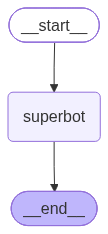

In [13]:
# Build the agent graph

def build_agent_graph_without_tool(checkpointer=None):
    """Build the streaming agent

    Args:
    
    checkpointer Saves the state between calls, e.g. MemorySaver(). None means no memory

    Returns:
    CompiledStateGraph: The compiled agent graph
    """


    builder = StateGraph(State)
    builder.add_node("superbot", super_bot)


    builder.add_edge(START, "superbot")
    builder.add_edge("superbot", END)

    return builder.compile(checkpointer=checkpointer)


memory = MemorySaver()
graph = build_agent_graph_without_tool(checkpointer=memory)
graph

In [14]:
config = {"configurable": {"thread_id": "2"}}

response = graph.invoke({"messages": "Hi, my name is KDB and i like football"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is KDB and i like football
================================== Ai Message ==================================

Hi KDB! Nice to meet you. ⚽️

Football is a great passion. Do you prefer watching it, playing it, or both? And do you have a favorite team or player? I’d love to hear what you enjoy the most about the game!


# Streaming with `.stream()` and `.astream()`

`graph.invoke(...)` waits until the whole graph is done and then returns the final state. In a chat app, the user sees nothing until the last node finishes. **Streaming** sends output back *while* the graph runs, one step at a time or one token at a time.

| Method | Type | Usage | When to use |
|---|---|---|---|
| `graph.invoke(...)` | Sync, blocking | `response = graph.invoke(inputs, config=config)` | You only need the final answer |
| `graph.stream(...)` | Sync generator | `for chunk in graph.stream(inputs, config=config): ...` | Notebooks, scripts, sync code |
| `graph.astream(...)` | Async generator | `async for chunk in graph.astream(inputs, config=config): ...` | Async apps (FastAPI, websockets) serving many users at once |

Both take the same arguments as `invoke` and work with the checkpointer. Pass the same `config` (same `thread_id`) and the streamed run is saved to that thread's memory, just like a normal call.

## Stream modes

The `stream_mode` argument sets what each chunk contains:

| `stream_mode` | Each chunk is | Use it to |
|---|---|---|
| `"updates"` (default) | `{node_name: update}`, only what that node returned | See which node ran and what it added |
| `"values"` | The **full state** after each step | Watch the whole `messages` list grow |
| `"messages"` | `(message_chunk, metadata)`, the LLM output **token by token** | Show a ChatGPT-style typing effect |
| `"custom"` | Anything a node sends with `get_stream_writer()` | Send progress updates like *"Searching the web..."* |
| `"debug"` | Checkpoint and task events | Debug the graph step by step |

You can pass a list, e.g. `stream_mode=["updates", "messages"]`. Each chunk then arrives as a `(mode, chunk)` tuple.

## `.stream()`: step by step

```python
config = {"configurable": {"thread_id": "2"}}

# "updates": one chunk per node that ran
for chunk in graph.stream({"messages": "Hi, I am KDB"}, config=config, stream_mode="updates"):
    print(chunk)  # {'superbot': {'messages': [AIMessage(...)]}}

# "values": the full state after each step
for chunk in graph.stream({"messages": "What is my name?"}, config=config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()
```

## `.stream()`: token by token

```python
for msg_chunk, metadata in graph.stream(
    {"messages": "Tell me a fun fact about football"}, config=config, stream_mode="messages"
):
    if msg_chunk.content and metadata["langgraph_node"] == "superbot":
        print(msg_chunk.content, end="", flush=True)
```

- The node still calls `llm.invoke(...)`. LangGraph picks up the tokens through callbacks, so you don't need to rewrite the node to use `llm.stream(...)`.
- `metadata["langgraph_node"]` names the node that produced the token. In the ReAct agent, filter on `"tool_calling_llm"` to print only the LLM's answer and skip the tool results.

## `.astream()`: the async version

It takes the same arguments and supports the same stream modes. Loop over it with `async for`:

```python
async for msg_chunk, metadata in graph.astream(
    {"messages": "Do you remember my name?"}, config=config, stream_mode="messages"
):
    if msg_chunk.content:
        print(msg_chunk.content, end="", flush=True)
```

- **In Jupyter**, the notebook already runs an event loop, so `async for` works directly in a cell.
- **In a `.py` script**, wrap the loop in `async def main(): ...` and call `asyncio.run(main())`.
- **Why async?** While one request waits for the LLM, the event loop can serve other requests, which is what a web server handling many chats needs. In a notebook, `.stream()` and `.astream()` print the same output.
- Sync nodes like `super_bot` work with `.astream()`: LangGraph runs them in a thread pool. For fully async execution, make the node async too: `async def super_bot(state): return {"messages": [await llm.ainvoke(state["messages"])]}`.

> **Beyond `stream_mode`:** `graph.astream_events(inputs, config=config, version="v2")` emits low-level events (`on_chat_model_stream`, `on_tool_start`, `on_tool_end`, ...) for every runnable inside the graph. Use it when you need that detail; for most chat UIs, `stream_mode="messages"` is enough.

In [15]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages": "Hi, my name is KDB and i like football"}, config=config, stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content='Hi KDB! Nice to meet you.\n\nFootball (soccer) is a fantastic sport with so much passion and strategy. Do you have a favorite team or a specific league you follow? Are you more of a fan of the tactical side, or do you just love the excitement of the game? ⚽️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 23, 'total_tokens': 89, 'completion_time': 0.130040503, 'completion_tokens_details': None, 'prompt_time': 0.001326448, 'prompt_tokens_details': None, 'queue_time': 0.045710411, 'total_time': 0.131366951}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d958-16d4-73f2-bc71-253244531f75-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 66, 'total_tokens': 89})]}}


In [17]:
for chunk in graph.stream({"messages": "Hi, my name is KDB and i like football, and i'm from india"}, config=config, stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Hi, my name is KDB and i like football', additional_kwargs={}, response_metadata={}, id='5aaca348-05a3-4322-9097-40bf2eb7ba35'), AIMessage(content='Hi KDB! Nice to meet you.\n\nFootball (soccer) is a fantastic sport with so much passion and strategy. Do you have a favorite team or a specific league you follow? Are you more of a fan of the tactical side, or do you just love the excitement of the game? ⚽️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 23, 'total_tokens': 89, 'completion_time': 0.130040503, 'completion_tokens_details': None, 'prompt_time': 0.001326448, 'prompt_tokens_details': None, 'queue_time': 0.045710411, 'total_time': 0.131366951}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d958-16d4-73f2-bc71-253244531f75-0', tool_calls=[], invalid_too

In [18]:
config = {"configurable": {"thread_id": "4"}}

for chunk in graph.stream({"messages": "Hi, my name is KDB and i like football"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hi KDB! It's nice to meet you. ⚽️\n\nFootball is a fantastic sport with so much passion and strategy. Do you have a favorite team or league you follow closely? Or maybe a particular player who inspires you?\n\nFeel free to share your thoughts, ask for match analysis, or just chat about your favorite moments in football history!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 23, 'total_tokens': 97, 'completion_time': 0.140274069, 'completion_tokens_details': None, 'prompt_time': 0.001354411, 'prompt_tokens_details': None, 'queue_time': 0.044390113, 'total_time': 0.14162848}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d95b-5a7c-7390-bc8b-56d58ad6367d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 74,

In [19]:

for chunk in graph.stream({"messages": "I also like cricket and i'm from india "}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is KDB and i like football', additional_kwargs={}, response_metadata={}, id='654d5695-25eb-48f0-83bb-71c0a68cdb2e'), AIMessage(content="Hi KDB! It's nice to meet you. ⚽️\n\nFootball is a fantastic sport with so much passion and strategy. Do you have a favorite team or league you follow closely? Or maybe a particular player who inspires you?\n\nFeel free to share your thoughts, ask for match analysis, or just chat about your favorite moments in football history!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 23, 'total_tokens': 97, 'completion_time': 0.140274069, 'completion_tokens_details': None, 'prompt_time': 0.001354411, 'prompt_tokens_details': None, 'queue_time': 0.044390113, 'total_time': 0.14162848}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

# `astream_events()`: every event inside the graph

`stream_mode` streams at the **graph level**: node updates, the state, or LLM tokens. `astream_events()` goes one level deeper. It reports every **runnable** inside the graph (the graph itself, each node, each chat model call, each tool call) when it **starts**, **streams**, and **ends**.

Use it when a UI needs more than the answer, for example showing *"Calling web_search..."* while a tool runs and then streaming the answer token by token.

## Each event is a dict

| Key | What it holds | Example |
|---|---|---|
| `event` | The event type: `on_<runnable type>_<start / stream / end>` | `"on_chat_model_stream"` |
| `name` | The runnable's name | `"LangGraph"`, `"superbot"`, `"ChatGroq"`, `"multiply"` |
| `data` | The payload: `input` on start, `chunk` on stream, `output` on end | `event["data"]["chunk"].content` |
| `metadata` | Run info: `thread_id`, `langgraph_node`, `langgraph_step`, ... | `event["metadata"]["langgraph_node"]` |
| `run_id`, `parent_ids` | IDs that link an event to the runs that started it | |
| `tags` | Tags attached to the runnable | |

## Common events

| Event | Fires when | Useful `data` |
|---|---|---|
| `on_chain_start` / `on_chain_end` | The graph or a node starts / ends | `input` / `output` |
| `on_chain_stream` | The graph or a node emits output | `chunk` |
| `on_chat_model_start` | An LLM call begins | |
| `on_chat_model_stream` | The LLM produces a token | `chunk` (an `AIMessageChunk`) |
| `on_chat_model_end` | The LLM call finishes | `output` (the full `AIMessage`, including `usage_metadata`) |
| `on_tool_start` / `on_tool_end` | A tool call starts / ends | `input` (the tool arguments) / `output` (the `ToolMessage`) |

One call to the `superbot` graph produces events in this order:

```
on_chain_start        LangGraph   <- the whole graph starts
on_chain_start        superbot    <- the node starts
on_chat_model_start   ChatGroq    <- the LLM call starts
on_chat_model_stream  ChatGroq    <- one event per token (many of these)
on_chat_model_end     ChatGroq    <- the LLM call ends
on_chain_stream       superbot    <- the node returns its update
on_chain_end          superbot    <- the node ends
on_chain_stream       LangGraph
on_chain_end          LangGraph   <- the graph ends
```

## `stream()` / `astream()` vs. `astream_events()`

| | `stream()` / `astream()` | `astream_events()` |
|---|---|---|
| Level | The graph: nodes and state | Every runnable: graph, nodes, LLMs, tools |
| Sync version | `stream()` | None, it is async only (`async for`) |
| Output | Small, focused chunks | Many events that you filter |
| Best for | Most chat apps | Tool-progress UIs, debugging, fine-grained control |

## Things to know

- **Pass `version="v2"`.** It is the default in current versions. `"v1"` is legacy and `"v3"` is experimental.
- **It emits a lot of events.** Filter them inside the loop with `event["event"]`, or at the source with `include_types=[...]`, `include_names=[...]`, `include_tags=[...]` (or the matching `exclude_*` arguments).
- **It works with memory.** Pass the same `config` (same `thread_id`) and the run is saved to that thread as usual.
- **Nodes don't need to change.** As with `stream_mode="messages"`, the node can keep calling `llm.invoke(...)` and you still get `on_chat_model_stream` token events.

The next cell prints every raw event. The cells after it show how to filter them.

In [20]:
config = {"configurable": {"thread_id": "4"}}

async for event in graph.astream_events({"messages": "Hi, my name is KDB and i like football adn i'm from india i follow PL and laliga"}, config=config, version='v2'):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': "Hi, my name is KDB and i like football adn i'm from india i follow PL and laliga"}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0d95f-3fa8-7443-9d9b-75e8c71cce01', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is KDB and i like football', additional_kwargs={}, response_metadata={}, id='654d5695-25eb-48f0-83bb-71c0a68cdb2e'), AIMessage(content="Hi KDB! It's nice to meet you. ⚽️\n\nFootball is a fantastic sport with so much passion and strategy. Do you have a favorite team or league you follow closely? Or maybe a particular player who inspires you?\n\nFeel free to share your thoughts, ask for match analysis, or just chat about your favorite moments in football history!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 23, 'total_tokens': 97, 'compl

In [21]:
## astream_events 1: see the flow of events
## Print only the event type, the runnable's name and the node it ran in

config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events(
    {"messages": "Hi, I'm KDB. Tell me one fact about the Premier League"},
    config=config,
    version="v2",
):
    # Token events fire once per token, so skip them here to keep the output short
    if event["event"] == "on_chat_model_stream":
        continue

    # metadata["langgraph_node"] names the graph node; graph-level events don't have it
    node = event["metadata"].get("langgraph_node", "-")
    print(f"{event['event']:<20} name={event['name']:<10} node={node}")

on_chain_start       name=LangGraph  node=-
on_chain_start       name=superbot   node=superbot
on_chat_model_start  name=ChatGroq   node=superbot
on_chat_model_end    name=ChatGroq   node=superbot
on_chain_stream      name=superbot   node=superbot
on_chain_end         name=superbot   node=superbot
on_chain_stream      name=LangGraph  node=-
on_chain_end         name=LangGraph  node=-


In [22]:
## astream_events 2: stream the answer token by token

async for event in graph.astream_events(
    {"messages": "What is my name and which league did I ask about?"},
    config=config,  # same thread_id, so the agent remembers the previous turn
    version="v2",
):
    # on_chat_model_stream fires once per token
    if event["event"] == "on_chat_model_stream":
        # data["chunk"] is an AIMessageChunk; .content is the new piece of text
        token = event["data"]["chunk"].content
        if token:  # skip empty chunks, e.g. the last one that only carries token usage
            print(token, end="", flush=True)

Your name is **KDB**, and you asked about the **Premier League**.

In [23]:
## astream_events 3: filter at the source and use the start / end events

async for event in graph.astream_events(
    {"messages": "Suggest one La Liga match I should watch"},
    config=config,
    version="v2",
    include_types=["chat_model"],  # keep only LLM events; other types: "chain", "tool", ...
    # include_names=["ChatGroq"],  # or filter by the runnable's name instead
):
    kind = event["event"]

    if kind == "on_chat_model_start":
        # Fires once, before the first token
        print(f"[{event['name']} started in node '{event['metadata']['langgraph_node']}']\n")

    elif kind == "on_chat_model_stream":
        print(event["data"]["chunk"].content, end="", flush=True)

    elif kind == "on_chat_model_end":
        # data["output"] is the complete AIMessage, so the token usage is available here
        print("\n\n[Token usage]", event["data"]["output"].usage_metadata)

[ChatGroq started in node 'superbot']

Since you are interested in top-tier football, the match you generally can't miss in La Liga is **El Clásico**: **Real Madrid vs. FC Barcelona**.

This is arguably the most high-stakes, high-profile rivalry in world football. It features two of the biggest clubs in history, often plays for the league title, and consistently draws massive global attention. Even if it’s not the "most important" match of the season in terms of points, the intensity and quality are usually at their peak.

If you want a slightly different flavor, **Atletico Madrid vs. Real Madrid** (derby del Madrid) is also an intense, tactical battle worth watching. But El Clásico is the iconic choice.

[Token usage] {'input_tokens': 219, 'output_tokens': 150, 'total_tokens': 369}


In [25]:
## astream_events 4: tool events with the ReAct agent
## Show which tools the agent calls, then stream its final answer

# `graph` is the superbot graph now, so rebuild the ReAct agent (web_search + multiply)
react_graph = build_agent_graph(tools, checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "react-1"}}

# The tools the agent itself can call. web_search calls TavilySearch inside it, and TavilySearch
# is a LangChain tool too, so it emits its own nested on_tool_start / on_tool_end events.
# Its output is a plain dict, not a ToolMessage, so skip those nested events.
agent_tools = {"web_search", "multiply"}

async for event in react_graph.astream_events(
    {"messages": "What is 12 times 7? Also find the latest Premier League news"},
    config=config,
    version="v2",
):
    kind = event["event"]

    if kind == "on_tool_start" and event["name"] in agent_tools:
        # data["input"] holds the arguments the LLM chose for this tool
        print(f"\n[calling {event['name']} with {event['data']['input']}]")

    elif kind == "on_tool_end" and event["name"] in agent_tools:
        # ToolNode wraps the tool's result in a ToolMessage; show only the start of it
        result = str(event["data"]["output"].content)
        print(f"[{event['name']} returned: {result[:100]}]\n")

    elif kind == "on_chat_model_stream":
        # Chunks that only carry a tool call have empty content, so this prints just the answer text
        print(event["data"]["chunk"].content, end="", flush=True)


[calling multiply with {'a': 12, 'b': 7}]

[calling web_search with {'query': 'latest Premier League news'}]
[multiply returned: 84]

[web_search returned: {"query": "latest Premier League news", "follow_up_questions": null, "answer": null, "images": [], "]

12 times 7 is 84.

For the latest Premier League news, here are a few current headlines and storylines:

- Manchester City moved three points clear at the top after a 5–3 win over Sunderland at the Etihad.
- Matheus Cunha scored a late, deflected equaliser for Manchester United against Fulham, denying Fulham their first league win of the season.
- Liverpool’s strong defensive performances under Andoni Iraola continue, including a winning return away at Bournemouth.
- Brentford remain unbeaten after putting three past Chelsea.
- Spurs suffered another defeat, with Aston Villa holding on for their first league win of the season.
- Everton extended their unbeaten run with a win over 10-man Ipswich.
- Leeds drew with Crystal Palace to